In [42]:
# building PSWM model and validating with the von Hejine Method
!pip install tabulate
import pandas as pd
from Bio import SeqIO 
import numpy as np
import seaborn as sns
from numpy import trapz
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [25]:
# import the files needed
fasta_file= "pos_cluster-results_rep_seq.fasta"
pos_info= pd.read_csv("positive_info.tsv", sep= '\t')

# map dictionaries accordingly
df_tr= pos_info[["UniprotAccession", "SPPosition"]]
sp_mapping_tr = dict(zip(df_tr["UniprotAccession"], df_tr["SPPosition"]))

# Load FASTA file and extract 15-aa motifs centered on the cleavage site for all positive sequences
# The cleavage site positions are taken from `sp_mapping_tr`, which maps each Uniprot ID to its SPPosition
def cutting_tr_motif(fasta_file, sp_mapping_tr):
    motifs_tr = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        if record.id in sp_mapping_tr:
            cut_pos = int(sp_mapping_tr[record.id])
            seq = str(record.seq)
            
            # only take motifs if there's enough sequence both sides
            if cut_pos >= 13 and cut_pos+2 <= len(seq):
                motif_tr = seq[cut_pos-13:cut_pos+2]
                motifs_tr.append(motif_tr)
           # motif_tr = seq[max(0, cut_pos-13):min(len(seq), cut_pos+2)]

    return motifs_tr

seqs_pos = cutting_tr_motif(fasta_file, sp_mapping_tr)

with open("motifs_pos.fasta", "w") as out:
    for i, motif in enumerate(seqs_pos, 1):
        out.write(f">motif_{i}\n{motif}\n")

# Define the 20 amino acids 
positions = range(-13, 2)
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Create an empty matrix of 20 rows (AAs) x 15 columns (motif positions)
pspm = pd.DataFrame(np.ones((len(amino_acids), len(positions))), columns= positions, index=amino_acids)
# print(pspm)

for seq in seqs_pos:
    for i, aa in enumerate(seq):
        pos = list(pspm.columns)[i]
        if aa in pspm.index:             
            pspm.loc[aa, pos] += 1

# total number per position of AA divided by the total number of sequences      
pspm= pspm/(len(seqs_pos)+20)

# Divide all the counts by the corresponding residue frequency in the SwissProt background distribution
swissprot_comp={ "L": 9.65,
    "A": 8.26,
    "G": 7.07,
    "V": 6.86,
    "E": 6.72,
    "S": 6.66,
    "I": 5.91,
    "K": 5.80,
    "R": 5.53,
    "D": 5.46,
    "T": 5.37,
    "P": 4.75,
    "N": 4.06,
    "Q": 3.93,
    "F": 3.87,
    "Y": 2.92,
    "M": 2.41,
    "H": 2.28,
    "C": 1.39,
    "W": 1.11}

def background (swissprot_comp, pspm):
    pswm = pspm.copy() 

    # For each amino acid, divide its frequency at each position
    # by its expected background frequency in SwissProt.
    # This highlights amino acids that occur more/less often
    # in the signal peptide motif than in general proteins
    
    for key in swissprot_comp:
        result = swissprot_comp[key]/ 100
        pswm.loc[key] = pspm.loc[key] / result
    return pswm


pswm = background(swissprot_comp, pspm)    

# convert the normalized PSWM values to log-odds scores

def log_odds_matrix(pswm, base=2):
    if base == 2:
        pswm= np.log2(pswm)
    return pswm

pswm= log_odds_matrix(pswm, base=2)


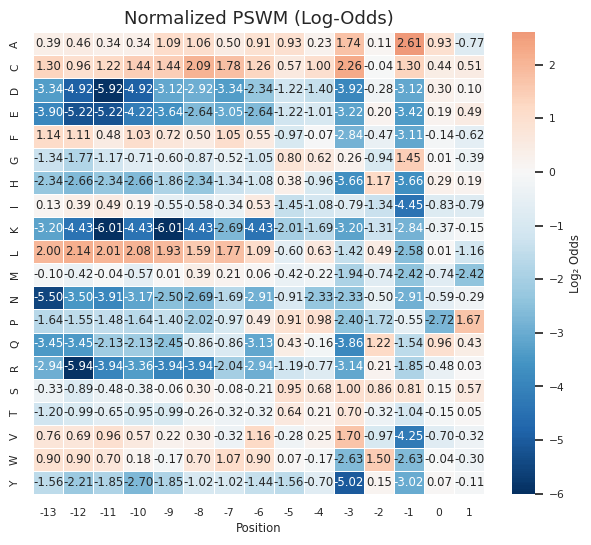

In [26]:
# Plot heatmap normalized PSWM
plt.figure(figsize=(16, 6))
sns.set(font_scale=0.7)

plt.subplot(1, 2, 1)
# red= high (mportant motif-defining residues) 
# blue= low (unlikely or disfavored residues)

sns.heatmap(
    pswm,
    cmap="RdBu_r",        
    center=0,            
    annot=True,           
    fmt=".2f",            
    cbar_kws={"label": "Log₂ Odds"},
    linewidths=0.4
)
plt.title("Normalized PSWM (Log-Odds)", fontsize=13)
plt.xlabel("Position")
plt.ylabel("")

# save and show
plt.savefig("pswm_heatmap.png", dpi=200, bbox_inches='tight')
# plt.show()

In [27]:
# creating a nunpy array
pswm_arr = pswm.to_numpy()

# preparing our folds by creating dictionaries with pos/neg keys, seq id and fasta sequence

def read_fasta_to_dict(file):
    seqs = {}
    with open(file, "r") as f:
        current_id = None
        current_seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_id is not None:
                    seqs[current_id] = "".join(current_seq)
                current_id = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None: 
            seqs[current_id] = "".join(current_seq) 
    return seqs

pos_dict = read_fasta_to_dict("pos_cluster-results_rep_seq.fasta")
neg_dict = read_fasta_to_dict("neg_cluster-results_rep_seq.fasta")

fold_files = ["fold_aa", "fold_ab", "fold_ac", "fold_ad", "fold_ae"]

fold_data = {}

for file_name in fold_files:
    pos_in_fold = []
    neg_in_fold = []
    
    with open(file_name, 'r') as f:
        for line in f:
            id= line.strip()
            # print (ids)
            if id in pos_dict:
                pos_in_fold.append((id, pos_dict[id]))
            elif id in neg_dict:
                neg_in_fold.append((id, neg_dict[id]))

    fold_data[file_name] = {
        "positives": pos_in_fold,
        "negatives": neg_in_fold}

In [28]:
# create an overall function for training folds

def training(train_pos, fasta_file, sp_mapping_tr, swissprot_comp):
    
    # build PSWM from positive sequences for current training folds.
    # Only extracts motifs from sequences that are in the training folds.

    # Restrict to IDs in training folds
    train_ids = [acc for acc, _ in train_pos]

    motifs_tr = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        if record.id in sp_mapping_tr and record.id in train_ids:
            cut_pos = int(sp_mapping_tr[record.id])
            seq = str(record.seq)
            if cut_pos >= 13 and cut_pos + 2 <= len(seq):
                motif_tr = seq[cut_pos-13:cut_pos+2]
                motifs_tr.append(motif_tr)

    print(f"Extracted {len(motifs_tr)} motifs from training positives.")

    # Build PSPM 
    positions = range(-13, 2)
    amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
    pspm = pd.DataFrame(np.ones((len(amino_acids), len(positions))), columns=positions, index=amino_acids)

    for seq in motifs_tr:
        for i, aa in enumerate(seq):
            if aa in pspm.index:
                pspm.loc[aa, list(pspm.columns)[i]] += 1

    pspm = pspm / (len(motifs_tr) + 20)

    # Normalize by background frequencies (get pswm)
    pswm = pspm.copy()
    for key in swissprot_comp:
        pswm.loc[key] = pspm.loc[key] / (swissprot_comp[key] / 100)

    pswm = np.log(pswm)
    return pswm


In [44]:
# Computes the maximum PSWM score for each sequence in a given fold using a sliding window
def scores_one_fold(data, pswm):
 
    pswm_arr = pswm.to_numpy()
    aa_to_idx = {aa: i for i, aa in enumerate(pswm.index)}
    pos_to_idx = {pos: i for i, pos in enumerate(pswm.columns)}

    window_size = 15
    index = list(range(-13, 2))
    results = {}

    for seq_id, seq in data.items():
        seq_scores = []
        # limit sliding to first 90 aa
        max_start = min(len(seq), 90) - window_size + 1 
        for i in range(max_start):
            window = seq[i:i + window_size]
            try:
                score = 0
                for aa, pos in zip(window, index):
                    score += pswm_arr[aa_to_idx[aa], pos_to_idx[pos]]
            except KeyError:
                score = np.nan
            seq_scores.append(score)
        results[seq_id] = max(seq_scores)
    return results



>>> RUN 1/5
Training folds: ['fold_ac', 'fold_ad', 'fold_ae']
Validation fold: fold_ab
Testing fold: fold_aa
Extracted 531 motifs from training positives.
Optimal threshold (validation): 6.437
F1=0.691, Precision=0.693, Recall=0.689, MCC=0.653
TP=122, TN=1375, FP=54, FN=55

>>> RUN 2/5
Training folds: ['fold_aa', 'fold_ad', 'fold_ae']
Validation fold: fold_ac
Testing fold: fold_ab
Extracted 528 motifs from training positives.
Optimal threshold (validation): 6.020
F1=0.707, Precision=0.645, Recall=0.782, MCC=0.674
TP=129, TN=1370, FP=71, FN=36

>>> RUN 3/5
Training folds: ['fold_aa', 'fold_ab', 'fold_ae']
Validation fold: fold_ad
Testing fold: fold_ac
Extracted 519 motifs from training positives.
Optimal threshold (validation): 6.212
F1=0.722, Precision=0.716, Recall=0.728, MCC=0.686
TP=131, TN=1372, FP=52, FN=49

>>> RUN 4/5
Training folds: ['fold_aa', 'fold_ab', 'fold_ac']
Validation fold: fold_ae
Testing fold: fold_ad
Extracted 522 motifs from training positives.
Optimal threshold (

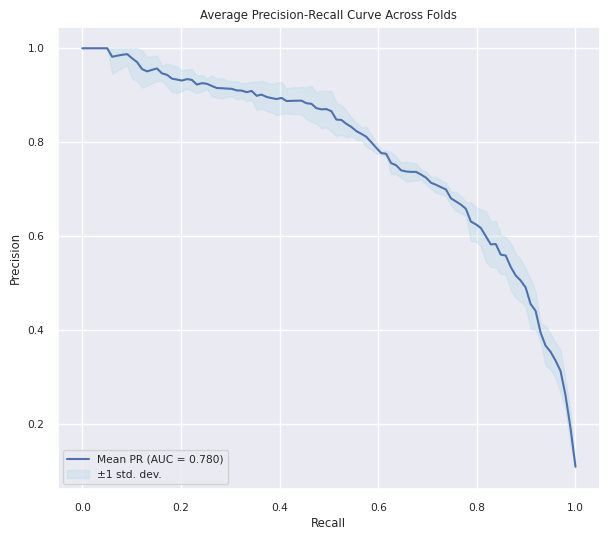

In [45]:
# run cross validation
from sklearn.metrics import (
    precision_recall_curve, f1_score, precision_score,
    recall_score, matthews_corrcoef, confusion_matrix
)
def cross_validation(fold_data, fold_files):
    metrics_all = {"F1": [], "Precision": [], "Recall": [], "MCC": []}
    thresholds_all = []
    confusion_summary = []
    all_precisions = []
    all_recalls = []

    for i, test_fold in enumerate(fold_files):
        val_fold = fold_files[(i + 1) % len(fold_files)]
        train_folds = [f for f in fold_files if f not in [test_fold, val_fold]]

        print(f"\n>>> RUN {i+1}/5")
        print(f"Training folds: {train_folds}")
        print(f"Validation fold: {val_fold}")
        print(f"Testing fold: {test_fold}")

        #  training 
        train_pos = sum([fold_data[f]["positives"] for f in train_folds], [])
        pswm = training(train_pos, fasta_file, sp_mapping_tr, swissprot_comp)

        # validation 
        val_pos = fold_data[val_fold]["positives"]
        val_neg = fold_data[val_fold]["negatives"]
        val_dict = dict(val_pos + val_neg)

        val_scores = scores_one_fold(val_dict, pswm)
        y_true_val = [1] * len(val_pos) + [0] * len(val_neg)
        y_scores_val = list(val_scores.values())

        precision, recall, thresholds = precision_recall_curve(y_true_val, y_scores_val)
        fscore = (2 * precision * recall) / (precision + recall + 1e-9)
        optimal_threshold = thresholds[np.argmax(fscore)]
        thresholds_all.append(optimal_threshold)

        all_precisions.append(precision)
        all_recalls.append(recall)

        print(f"Optimal threshold (validation): {optimal_threshold:.3f}")

        # Testing 
        test_pos = fold_data[test_fold]["positives"]
        test_neg = fold_data[test_fold]["negatives"]
        test_dict = dict(test_pos + test_neg)

        test_scores = scores_one_fold(test_dict, pswm)
        y_true_test = [1] * len(test_pos) + [0] * len(test_neg)
        y_pred_test = [int(s >= optimal_threshold) for s in test_scores.values()]

        # Metrics
        f1 = f1_score(y_true_test, y_pred_test)
        prec = precision_score(y_true_test, y_pred_test)
        rec = recall_score(y_true_test, y_pred_test)
        mcc = matthews_corrcoef(y_true_test, y_pred_test)

        cm = confusion_matrix(y_true_test, y_pred_test)
        tn, fp, fn, tp = cm.ravel()

        print(f"F1={f1:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, MCC={mcc:.3f}")
        print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")

        metrics_all["F1"].append(f1)
        metrics_all["Precision"].append(prec)
        metrics_all["Recall"].append(rec)
        metrics_all["MCC"].append(mcc)
        confusion_summary.append([test_fold, tp, tn, fp, fn])

    # Confusion table
    print("\n Confusion Matrices per Fold ")
    confusion_df = pd.DataFrame(confusion_summary, columns=["Fold", "TP", "TN", "FP", "FN"])
    print(confusion_df.to_markdown(index=False))

    # Final metrics 
    print("\n CROSS-VALIDATION RESULTS ")
    summary_data = []
    for metric, vals in metrics_all.items():
        mean_val = np.mean(vals)
        se_val = np.std(vals) / np.sqrt(len(vals))
        summary_data.append([metric, f"{mean_val:.3f} ± {se_val:.3f}"])
    summary_data.append(["Avg Threshold", f"{np.mean(thresholds_all):.3f}"])

    summary_df = pd.DataFrame(summary_data, columns=["Metric", "Value"])
    print(summary_df.to_markdown(index=False))

    return metrics_all, all_precisions, all_recalls, confusion_df


# Precision-Recall Curve Plot
def plot_average_precision_recall(all_precisions, all_recalls):
    mean_recall_axis = np.linspace(0, 1, 100)
    interpolated_precisions = []

    for precision, recall in zip(all_precisions, all_recalls):
        recall_increasing = recall[::-1]
        precision_increasing = precision[::-1]
        interp_precision = np.interp(mean_recall_axis, recall_increasing, precision_increasing)
        interpolated_precisions.append(interp_precision)

    interpolated_precisions = np.array(interpolated_precisions)
    mean_precision_curve = np.mean(interpolated_precisions, axis=0)
    std_precision = np.std(interpolated_precisions, axis=0)
    pr_auc = trapz(mean_precision_curve, mean_recall_axis)

    plt.figure(figsize=(7, 6))
    plt.plot(mean_recall_axis, mean_precision_curve, color='b',
             label=f'Mean PR (AUC = {pr_auc:.3f})')
    plt.fill_between(mean_recall_axis,
                     np.maximum(mean_precision_curve - std_precision, 0),
                     np.minimum(mean_precision_curve + std_precision, 1),
                     color='lightblue', alpha=0.3,
                     label='±1 std. dev.')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Average Precision-Recall Curve Across Folds")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.savefig("prc.png", dpi=200, bbox_inches='tight')
    plt.show()


# Run everything 
fold_files = ["fold_aa", "fold_ab", "fold_ac", "fold_ad", "fold_ae"]
results, all_precisions, all_recalls, confusion_df = cross_validation(fold_data, fold_files)
plot_average_precision_recall(all_precisions, all_recalls)
